import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [3]:
df = pd.read_csv("../data/retail_store_sales.csv")

print("Dataset imported successfully!")

Dataset imported successfully!


In [4]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [6]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12575
Columns: 11


In [27]:
original_df = pd.read_csv("../data/retail_store_sales.csv")

The dataset contains 12,575 transactions and 11 columns. Numeric columns (Price Per Unit, Quantity, Total Spent) and the Item and Discount Applied columns contain missing values. There are no duplicate rows.

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}) \
  .query("missing_count > 0") \
  .sort_values("missing_count", ascending=False)


,missing_count,missing_pct
Discount Applied,4199,33.39
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80


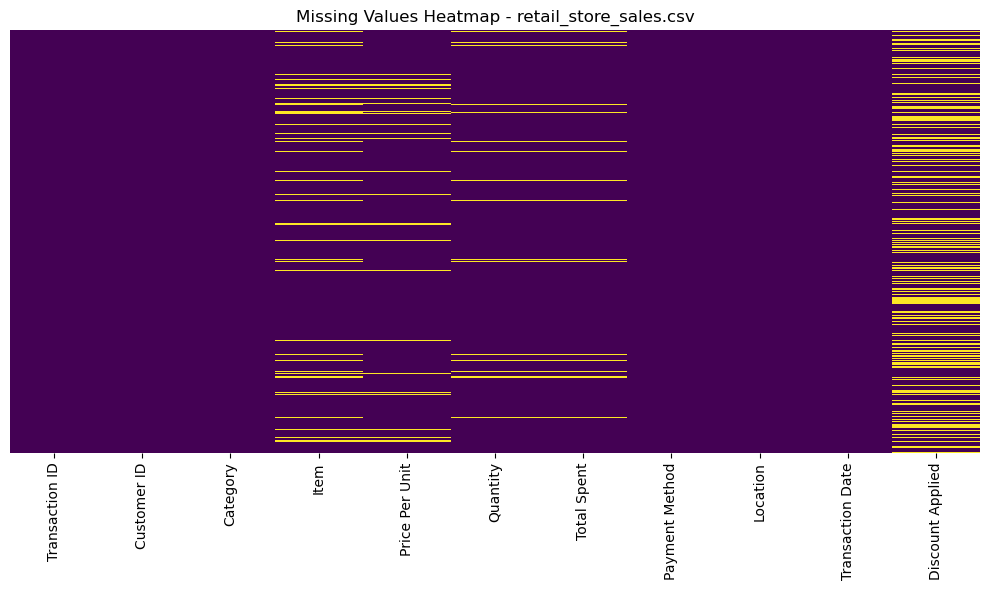

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap - retail_store_sales.csv")
plt.tight_layout()
plt.show()


In [14]:
mask_price = df["Price Per Unit"].isna() & df["Quantity"].notna() & df["Total Spent"].notna()
df.loc[mask_price, "Price Per Unit"] = df.loc[mask_price, "Total Spent"] / df.loc[mask_price, "Quantity"]
 
mask_qty = df["Quantity"].isna() & df["Price Per Unit"].notna() & df["Total Spent"].notna()
df.loc[mask_qty, "Quantity"] = df.loc[mask_qty, "Total Spent"] / df.loc[mask_qty, "Price Per Unit"]
 
mask_total = df["Total Spent"].isna() & df["Price Per Unit"].notna() & df["Quantity"].notna()
df.loc[mask_total, "Total Spent"] = df.loc[mask_total, "Price Per Unit"] * df.loc[mask_total, "Quantity"]
 
print("Remaining missing after recovery:")
print(df[["Price Per Unit", "Quantity", "Total Spent"]].isna().sum())


Remaining missing after recovery:
Price Per Unit      0
Quantity          604
Total Spent       604
dtype: int64


In [15]:
for col in ["Price Per Unit", "Quantity", "Total Spent"]:
    df[col] = df.groupby("Category")[col].transform(lambda x: x.fillna(x.median()))
    
df["Total Spent"] = df["Price Per Unit"] * df["Quantity"]
print(df[["Price Per Unit", "Quantity", "Total Spent"]].isna().sum())



Price Per Unit    0
Quantity          0
Total Spent       0
dtype: int64


In [16]:
df["Item"] = df["Item"].fillna("Unknown_Item")
print(df["Item"].isna().sum())


0


In [17]:
df["Discount Applied"] = df["Discount Applied"].fillna(False)
 
print(df["Discount Applied"].value_counts(dropna=False))


Discount Applied
False    8356
True     4219
Name: count, dtype: int64


C:\Users\samru\AppData\Local\Temp\ipykernel_12844\948033064.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Discount Applied"] = df["Discount Applied"].fillna(False)


In [18]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate Transaction IDs:", df["Transaction ID"].duplicated().sum())
 
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)


Fully duplicated rows: 0
Duplicate Transaction IDs: 0
Shape after duplicate removal: (12575, 11)


In [19]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)
print(df.columns.tolist())
# Cell 14 - fix data types
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["quantity"] = df["quantity"].round().astype(int)
df["discount_applied"] = df["discount_applied"].astype(bool)
 
df.dtypes


['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date', 'discount_applied']


transaction_id              object
customer_id                 object
category                    object
item                        object
price_per_unit             float64
quantity                     int32
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
discount_applied              bool
dtype: object

In [20]:
numeric_cols = ["price_per_unit", "quantity", "total_spent"]
 
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, "
          f"bounds=({lower:.2f}, {upper:.2f}), outliers={len(outliers)}")


price_per_unit: Q1=14.0, Q3=33.5, IQR=19.5, bounds=(-15.25, 62.75), outliers=0
quantity: Q1=3.0, Q3=8.0, IQR=5.0, bounds=(-4.50, 15.50), outliers=0
total_spent: Q1=52.0, Q3=192.0, IQR=140.0, bounds=(-158.00, 402.00), outliers=60


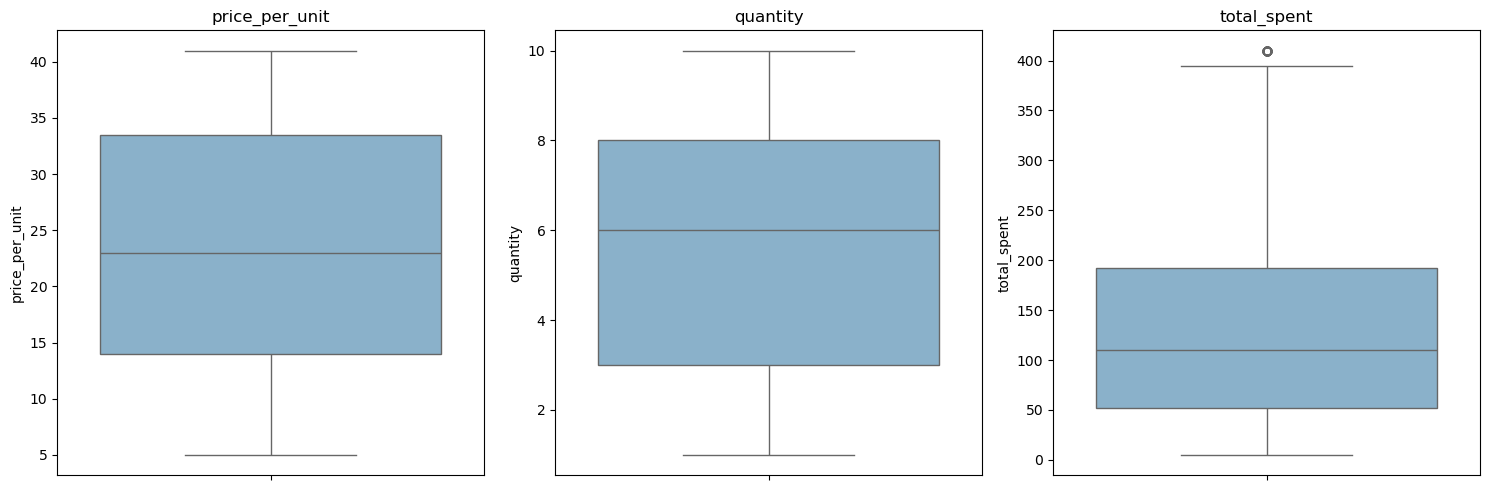

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#7FB3D5")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [22]:
Q1 = df["total_spent"].quantile(0.25)
Q3 = df["total_spent"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
 
df["total_spent"] = df["total_spent"].clip(lower, upper)


In [23]:
df_encoded = pd.get_dummies(
    df,
    columns=["payment_method", "location"],
    drop_first=True
)
 
df_encoded.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,transaction_date,discount_applied,payment_method_Credit Card,payment_method_Digital Wallet,location_Online
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,2024-04-08,True,False,True,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,2023-07-23,True,False,True,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,2022-10-05,False,True,False,True
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,2022-05-07,False,True,False,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,2022-10-02,False,False,True,True


In [24]:
from sklearn.preprocessing import LabelEncoder
 
le = LabelEncoder()
df_encoded["category_encoded"] = le.fit_transform(df["category"])
 
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(category_mapping)


{'Beverages': 0, 'Butchers': 1, 'Computers and electric accessories': 2, 'Electric household essentials': 3, 'Food': 4, 'Furniture': 5, 'Milk Products': 6, 'Patisserie': 7}


In [25]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
df.describe()


Shape: (12575, 11)

Missing values:
transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64

Data types:
transaction_id              object
customer_id                 object
category                    object
item                        object
price_per_unit             float64
quantity                     int32
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
discount_applied              bool
dtype: object


,price_per_unit,quantity,total_spent,transaction_date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.369304,5.552922,130.036938,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,52.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,110.000000,2023-07-13 00:00:00
75%,33.500000,8.000000,192.000000,2024-04-24 00:00:00
max,41.000000,10.000000,402.000000,2025-01-18 00:00:00
std,10.748728,2.790274,93.425533,NaN


In [26]:
df.to_csv("../data/retail_store_sales_cleaned.csv", index=False)
 
df_encoded.to_csv("../data/retail_store_sales_encoded.csv", index=False)
 
print("Saved retail_store_sales_cleaned.csv and retail_store_sales_encoded.csv")


Saved retail_store_sales_cleaned.csv and retail_store_sales_encoded.csv


In [28]:
comparison = pd.DataFrame({
    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],

    "Before":[
        original_df.shape[0],
        original_df.shape[1],
        original_df.isnull().sum().sum(),
        original_df.duplicated().sum()
    ],

    "After":[
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

comparison

,Metric,Before,After
0,Rows,12575,12575
1,Columns,11,11
2,Missing Values,7229,0
3,Duplicate Rows,0,0


# Data Cleaning Summary

## Dataset Overview

The retail sales dataset initially contained **12,575 rows and 11 columns**. A comprehensive data quality assessment was performed to identify missing values, data type inconsistencies, naming issues, and potential outliers before proceeding with analysis.

## Cleaning Actions Performed

### Missing Value Treatment

Several columns contained missing values, including **item**, **price_per_unit**, **quantity**, **total_spent**, and **discount_applied**.

* Missing values in **item** were replaced with **"Unknown_Item"** to preserve transaction records.
* Missing values in **discount_applied** were filled with **False**, assuming that no discount was applied when the information was unavailable.
* Missing values in **price_per_unit**, **quantity**, and **total_spent** were recovered whenever possible using the business relationship:

\text{total_spent} = \text{price_per_unit} \times \text{quantity}

* Any remaining missing numeric values were imputed using category-wise median values to maintain realistic data distributions.

### Data Standardization

To improve consistency and usability:

* Column names were converted from title case to **snake_case** format.
* The **transaction_date** column was converted from text format (`object`) to `datetime64`.
* The **quantity** column was converted to integer format after handling missing values.
* The **discount_applied** column was standardized to Boolean format.

### Duplicate Records

A duplicate record check was performed, and **no duplicate rows** were found in the dataset.

### Outlier Detection

Outliers were examined in the following numerical columns:

* price_per_unit
* quantity
* total_spent

The **Interquartile Range (IQR)** method and box plots were used to identify unusually large or small values. Potential outliers were reviewed to ensure data quality before modeling.

### Feature Encoding

To prepare the dataset for machine learning:

* **payment_method** and **location** were transformed using One-Hot Encoding.
* **category** was transformed using Label Encoding.

This produced a model-ready dataset suitable for exploratory analysis and predictive modeling.

## Data Quality Improvement Summary

| Metric                   | Before Cleaning | After Cleaning             |
| ------------------------ | --------------- | -------------------------- |
| Total Rows               | 12,575          | 12,575                     |
| Total Columns            | 11              | 11–13 (+ encoded features) |
| Missing item             | 1,213           | 0                          |
| Missing price_per_unit   | 609             | 0                          |
| Missing quantity         | 604             | 0                          |
| Missing total_spent      | 604             | 0                          |
| Missing discount_applied | 4,199           | 0                          |
| Duplicate Rows           | 0               | 0                          |
| Column Naming            | Mixed Format    | snake_case                 |
| transaction_date Type    | object          | datetime64                 |
| quantity Type            | float           | int                        |

## Conclusion

The dataset was successfully cleaned and transformed into an analysis-ready format. All missing values were addressed, data types were standardized, column names were normalized, and categorical variables were encoded for machine learning applications. The cleaned dataset was exported as **retail_store_sales_cleaned.csv** and subsequently used for exploratory data analysis and sales prediction modeling.
